In [132]:
import numpy as np
from OptimalBattery.util import build_combinations
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as ticker

In [15]:
n_tasks = 29
n_parcel = 32

In [41]:
VL_rand = Vs = np.random.normal(0, 1, (n_tasks, n_parcel))
GL_rand = VL_rand @ VL_rand.T

offsets = np.logspace(-10, 10, num=1000)
D = build_combinations(G_lib=GL_rand,strategy='random',n_iter=1000,offs = offsets, n_tasks=6,seed=1)

Text(0.5, 1.0, 'Correlation between log_det and max_var across Offsets')

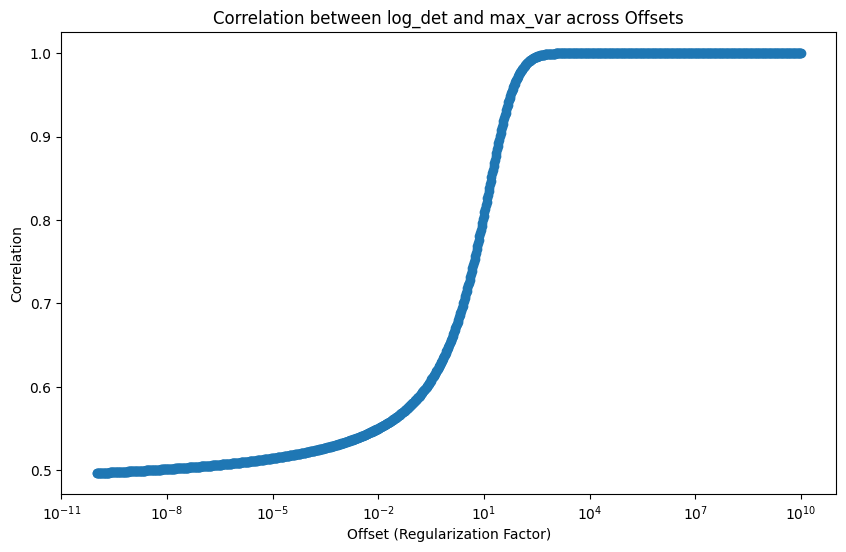

In [21]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D[D['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between log_det and max_var across Offsets')



Text(0.5, 1.0, 'Correlation between min_est and max_var across Offsets')

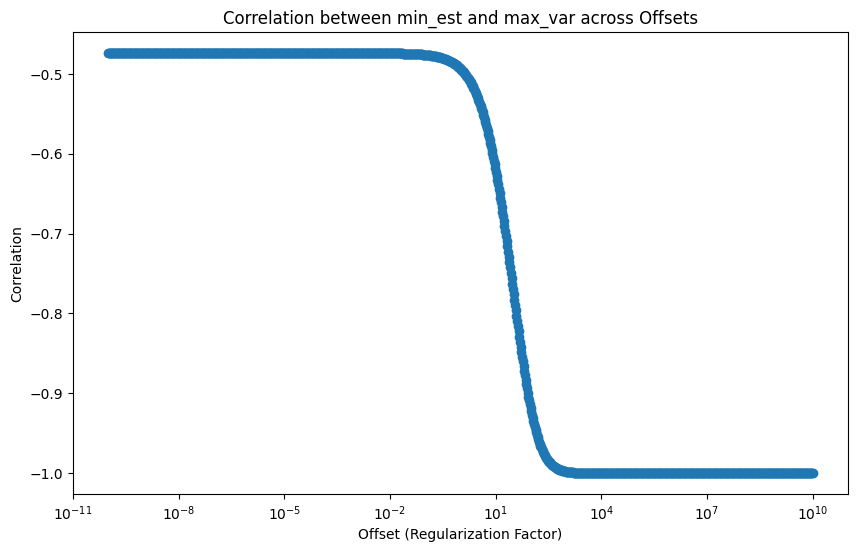

In [22]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D[D['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['min_est'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and max_var across Offsets')

Offset with highest correlation: 13.52480870417874 (Correlation: -0.9613214874489179)


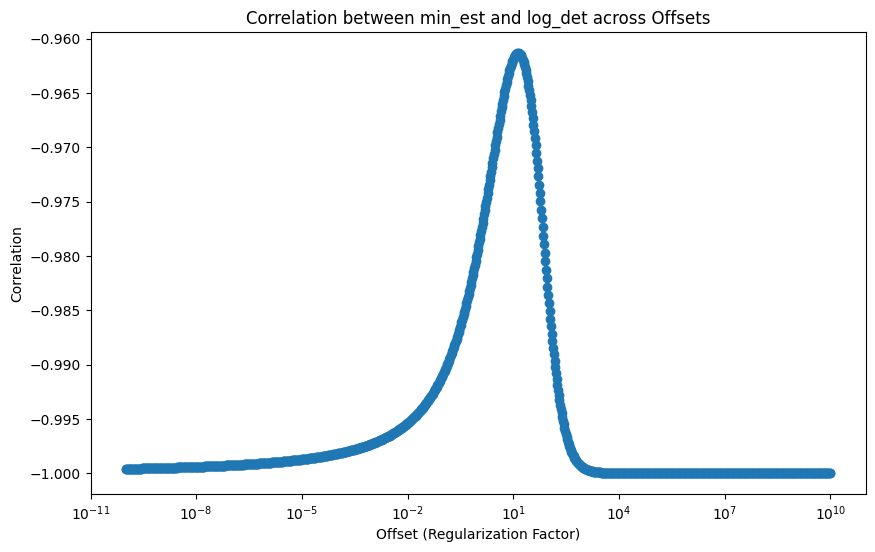

In [24]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D[D['offset'] == offset]
    corr, _ = pearsonr(data['min_est'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and log_det across Offsets')


# print regularization factor with highest correlation
max_corr = max(corr_list)
max_corr_offset = offsets[corr_list.index(max_corr)]
print(f'Offset with highest correlation: {max_corr_offset} (Correlation: {max_corr})')

In [ ]:
corr_min_est_n_unique = []
corr_log_det_n_unique = []

for offset in offsets:
    data = D[D['offset'] == offset]
    
    corr_min_est, _ = pearsonr(data['min_est'], data['n_unique'])
    corr_min_est_n_unique.append(corr_min_est)
    corr_log_det, _ = pearsonr(data['log_det'], data['n_unique'])
    corr_log_det_n_unique.append(corr_log_det)

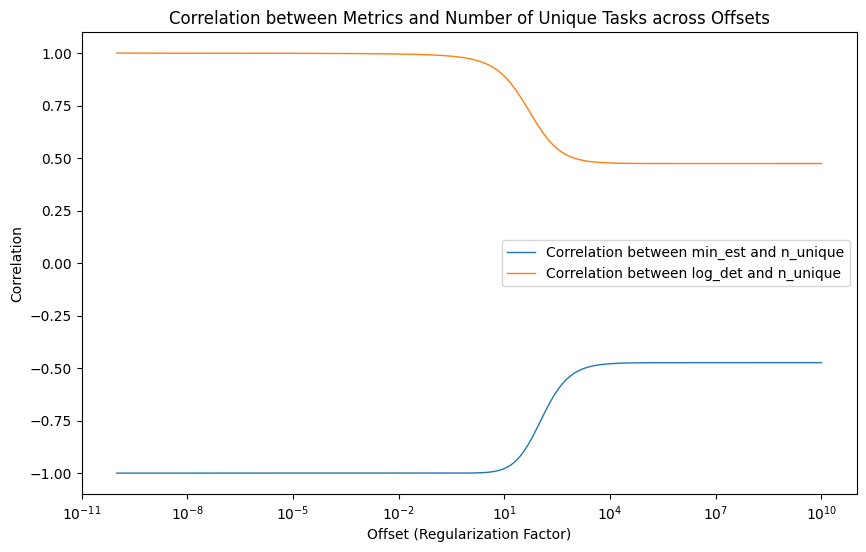

In [ ]:
# Plotting the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_min_est_n_unique, label='Correlation between min_est and n_unique', linewidth=1)
plt.plot(offsets, corr_log_det_n_unique, label='Correlation between log_det and n_unique', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between Metrics and Number of Unique Tasks across Offsets')
plt.legend()
plt.show()

# mdtb covariance

<Axes: >

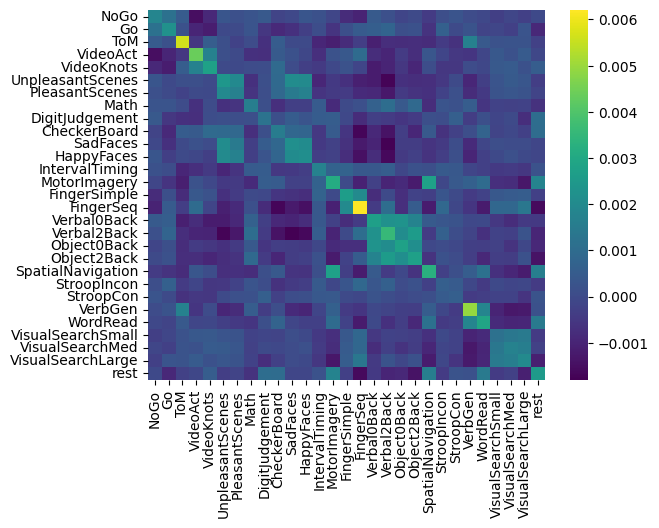

In [43]:
from IndividualParcellation.global_config import *
import numpy as np
import seaborn as sns
from Functional_Fusion.dataset import DataSetMDTB
import Functional_Fusion.atlas_map as am
import PcmPy as pcm
import os

base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'
space = 'SUIT3'
atlas, _ = am.get_atlas(space)


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
task_names = info_mdtb_1.cond_name.values


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

task_matrix = data_mdtb_s1 
task_matrix[np.isnan(task_matrix)] = 0

cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(task_matrix.shape[0]):
    Gs,E = pcm.util.est_G_crossval(task_matrix[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

In [46]:
D_mdtv = build_combinations(G_lib=G_individuals_averaged,strategy='random',n_iter=1000,offs = offsets, n_tasks=8,seed=3)

/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


Text(0.5, 1.0, 'Correlation between log_det and max_var across Offsets')

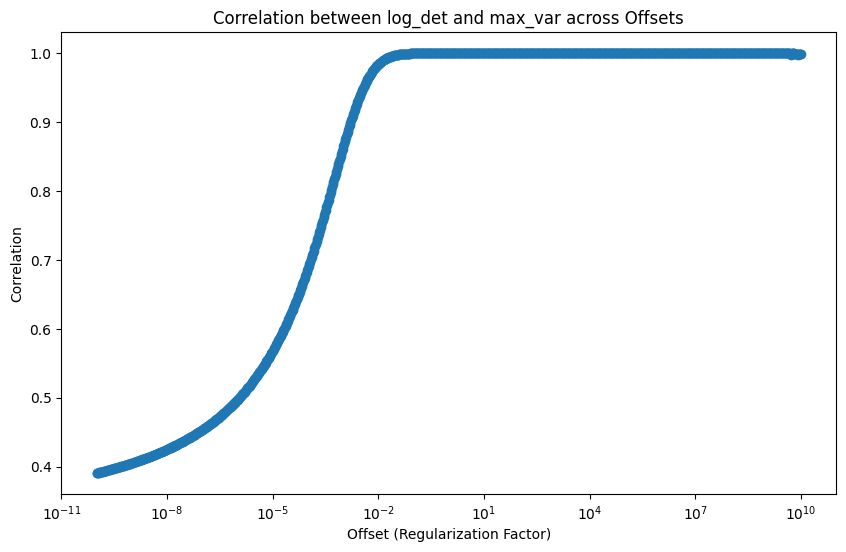

In [48]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between log_det and max_var across Offsets')


Text(0.5, 1.0, 'Correlation between min_est and max_var across Offsets')

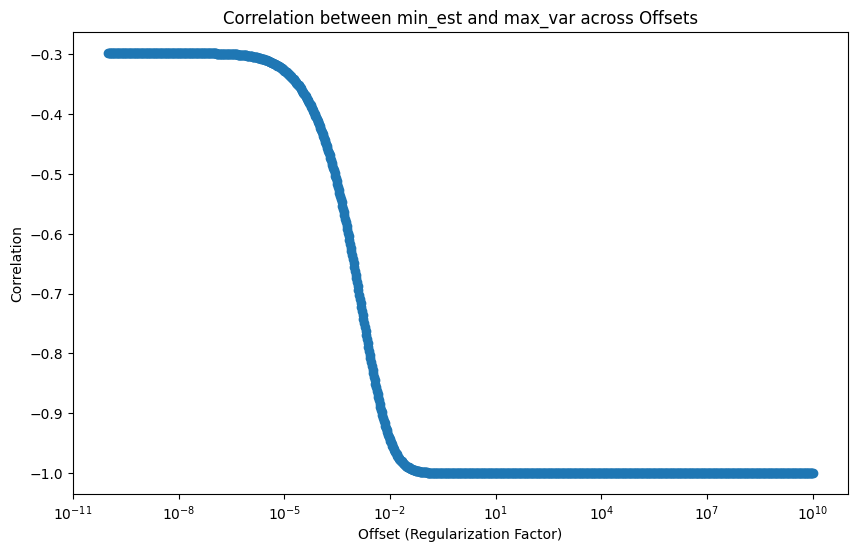

In [47]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['min_est'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and max_var across Offsets')


Offset with highest correlation: 6.696160054853215e-05 (Correlation: -0.92384557054294)


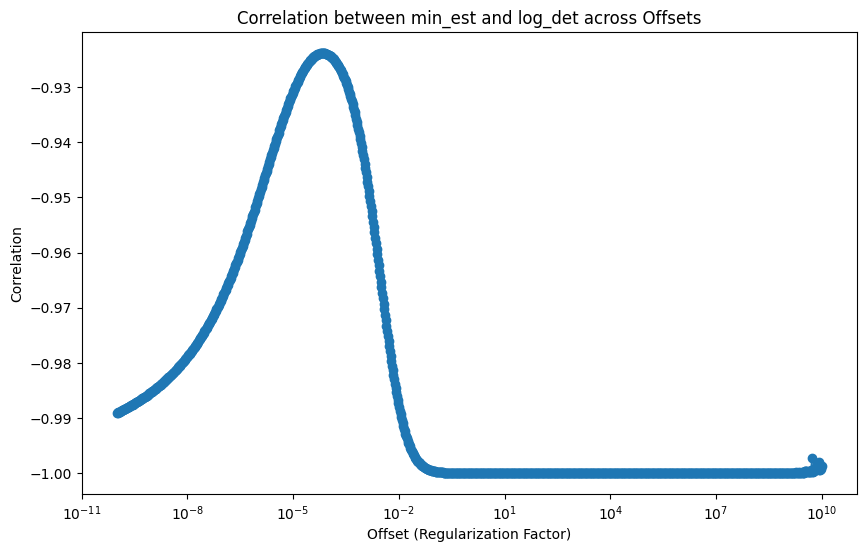

In [49]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    corr, _ = pearsonr(data['min_est'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and log_det across Offsets')

# print regularization factor with highest correlation
max_corr = max(corr_list)
max_corr_offset = offsets[corr_list.index(max_corr)]
print(f'Offset with highest correlation: {max_corr_offset} (Correlation: {max_corr})')


In [50]:
# print correaltion betewen max_var and log det at the offset with highest correlation
data = D_mdtv[D_mdtv['offset'] == max_corr_offset]
corr, _ = pearsonr(data['max_var'], data['log_det'])
print(f'Correlation between max_var and log_det at offset with highest correlation: {corr}')

# print correaltion betewen max_var and min_est at the offset with highest correlation
corr, _ = pearsonr(data['max_var'], data['min_est'])
print(f'Correlation between max_var and min_est at offset with highest correlation: {corr}')


Correlation between max_var and log_det at offset with highest correlation: 0.6620377461493794
Correlation between max_var and min_est at offset with highest correlation: -0.3946615453916075


/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


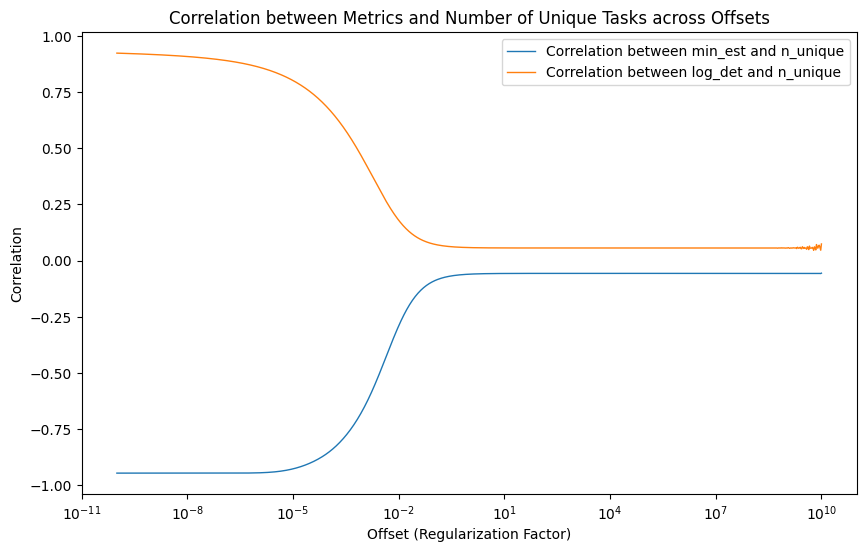

In [ ]:
corr_min_est_n_unique = []
corr_log_det_n_unique = []

for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    
    corr_min_est, _ = pearsonr(data['min_est'], data['n_unique'])
    corr_min_est_n_unique.append(corr_min_est)
    corr_log_det, _ = pearsonr(data['log_det'], data['n_unique'])
    corr_log_det_n_unique.append(corr_log_det)
# Plotting the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_min_est_n_unique, label='Correlation between min_est and n_unique', linewidth=1)
plt.plot(offsets, corr_log_det_n_unique, label='Correlation between log_det and n_unique', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between Metrics and Number of Unique Tasks across Offsets')
plt.legend()
plt.show()

# Can log_det and min_est disagree?

In [64]:
matrix_A = np.array([
    [5.0, 4.5, 4.5],
    [4.5, 5.0, 4.5],
    [4.5, 4.5, 5.0]
])

matrix_B = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.5, 0.0],
    [0.0, 0.0, 2.0]
])

In [65]:
# get eigenvalues
eig_A = np.linalg.eigvals(matrix_A)
eig_B = np.linalg.eigvals(matrix_B)

# get sum of the logs
log_det_A = np.sum(np.log(eig_A))
log_det_B = np.sum(np.log(eig_B))

# get the min_est which is sum of the inverses
min_est_A = np.sum(1/eig_A)
min_est_B = np.sum(1/eig_B)

#print
print(f'matrix A')
print(f'eigenvalues: {eig_A}')
print(f'log_det: {log_det_A}')
print(f'min_est: {min_est_A}')
print(f'matrix B')
print(f'eigenvalues: {eig_B}')
print(f'log_det: {log_det_B}')
print(f'min_est: {min_est_B}')


matrix A
eigenvalues: [ 0.5 14.   0.5]
log_det: 1.2527629684953676
min_est: 4.071428571428573
matrix B
eigenvalues: [1.  1.5 2. ]
log_det: 1.0986122886681096
min_est: 2.1666666666666665


# They can disagree, they contain info about var and covariance to what extent what do they care about the most?

In [138]:
def compute_log_det(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    eigenvalues = np.linalg.eigvalsh(cov_matrix_reg)
    log_det = np.sum(np.log(eigenvalues))
    return log_det

def compute_min_est(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    eigenvalues = np.linalg.eigvalsh(cov_matrix_reg)
    min_est = np.sum(1 / eigenvalues)
    return min_est


In [147]:
variance_values = np.linspace(1, 10, 200)
correlation_values = np.linspace(0, 0.99, 200)
offset_values = [1e-8, 1e-6, 1e-4, 1e-2, 1, 1e2, 1e4, 1e6, 1e8]

offsets = []
perc_var_log_dets = []
perc_corr_log_dets = []
perc_var_min_ests = []
perc_corr_min_ests = []




In [148]:
for offset in offset_values:
    variance_list = []
    correlation_list = []
    log_det_values = []
    min_est_values = []

    for variance in variance_values:
        for correlation in correlation_values:
            covariance = correlation * variance

            # Create covariance matrix (3x3 for simplicity)
            cov_matrix = np.full((3, 3), covariance)
            np.fill_diagonal(cov_matrix, variance)

            log_det = compute_log_det(cov_matrix, offset)
            min_est = compute_min_est(cov_matrix, offset)

            variance_list.append(variance)
            correlation_list.append(correlation)
            log_det_values.append(log_det)
            min_est_values.append(min_est)

    variance_array = np.array(variance_list)
    correlation_array = np.array(correlation_list)
    X = np.vstack((variance_array, correlation_array)).T
    y_log_det = np.array(log_det_values)
    y_min_est = np.array(min_est_values)

    # regression for log_det
    model_log_det = LinearRegression()
    model_log_det.fit(X, y_log_det)
    coeff_log_det = model_log_det.coef_

    # regression for min_est
    model_min_est = LinearRegression()
    model_min_est.fit(X, y_min_est)
    coeff_min_est = model_min_est.coef_

    # Calculate percentages
    sum_coeff_log_det = np.sum(np.abs(coeff_log_det))
    sum_coeff_min_est = np.sum(np.abs(coeff_min_est))

    perc_var_log_det = (abs(coeff_log_det[0]) / sum_coeff_log_det) * 100
    perc_corr_log_det = (abs(coeff_log_det[1]) / sum_coeff_log_det) * 100

    perc_var_min_est = (abs(coeff_min_est[0]) / sum_coeff_min_est) * 100
    perc_corr_min_est = (abs(coeff_min_est[1]) / sum_coeff_min_est) * 100

    offsets.append(offset)
    perc_var_log_dets.append(perc_var_log_det)
    perc_corr_log_dets.append(perc_corr_log_det)
    perc_var_min_ests.append(perc_var_min_est)
    perc_corr_min_ests.append(perc_corr_min_est)

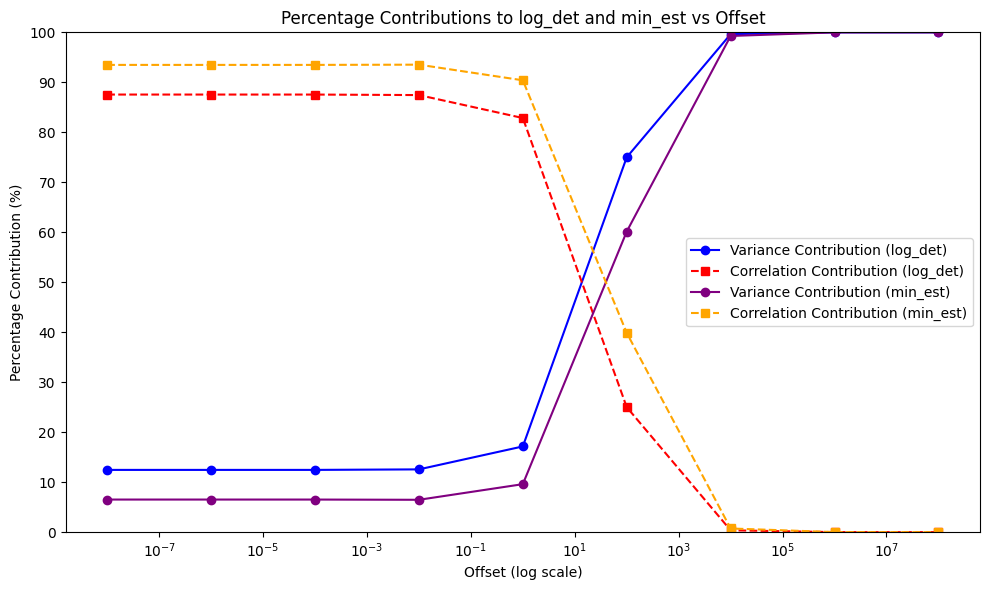

In [149]:

offsets_array = np.array(offsets)
plt.figure(figsize=(10, 6))

# Plot contributions for log_det
plt.plot(offsets_array, perc_var_log_dets, label='Variance Contribution (log_det)', marker='o', linestyle='-', color='blue')
plt.plot(offsets_array, perc_corr_log_dets, label='Correlation Contribution (log_det)', marker='s', linestyle='--', color='red')

# Plot contributions for min_est
plt.plot(offsets_array, perc_var_min_ests, label='Variance Contribution (min_est)', marker='o', linestyle='-', color='purple')
plt.plot(offsets_array, perc_corr_min_ests, label='Correlation Contribution (min_est)', marker='s', linestyle='--', color='orange')

plt.xscale('log')
plt.xlabel('Offset (log scale)')
plt.ylabel('Percentage Contribution (%)')
plt.title('Percentage Contributions to log_det and min_est vs Offset')

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.ylim(0, 100)

# Add a legend
plt.legend()
plt.tight_layout()
plt.show()
